In [1]:
import os

project_path = os.path.join(os.path.expanduser("~"), "Desktop", "Customer_Churn_Project")

folders = ["data", "images", "sql", "dashboard", "notebooks"]
for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)
    print(f"✅ Created: {folder}")

print("\n📁 Project folder ready at:")
print(project_path)

✅ Created: data
✅ Created: images
✅ Created: sql
✅ Created: dashboard
✅ Created: notebooks

📁 Project folder ready at:
C:\Users\PRIYANKA MANDAPPA\Desktop\Customer_Churn_Project


In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Set paths
project_path = os.path.join(os.path.expanduser("~"), "Desktop", "Customer_Churn_Project")
data_path = os.path.join(project_path, "data")
images_path = os.path.join(project_path, "images")

plt.style.use('seaborn-v0_8')
print("✅ All libraries imported!")

✅ All libraries imported!


In [4]:
# Load dataset
df = pd.read_csv(os.path.join(data_path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

print("✅ Dataset loaded!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

✅ Dataset loaded!
Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [6]:
# TotalCharges is object type — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many nulls appeared
print("Nulls in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# Fill nulls with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn to numeric
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID — not needed for analysis
df.drop('customerID', axis=1, inplace=True)

print("✅ Data cleaning done!")
print("Shape:", df.shape)

Nulls in TotalCharges after conversion: 11
✅ Data cleaning done!
Shape: (7043, 21)


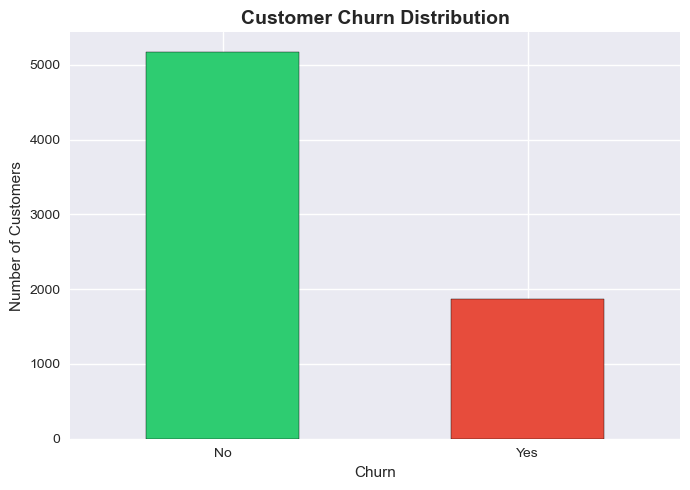

✅ Chart saved!


In [7]:
plt.figure(figsize=(7, 5))
colors = ['#2ecc71', '#e74c3c']
df['Churn'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(images_path, '01_churn_distribution.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

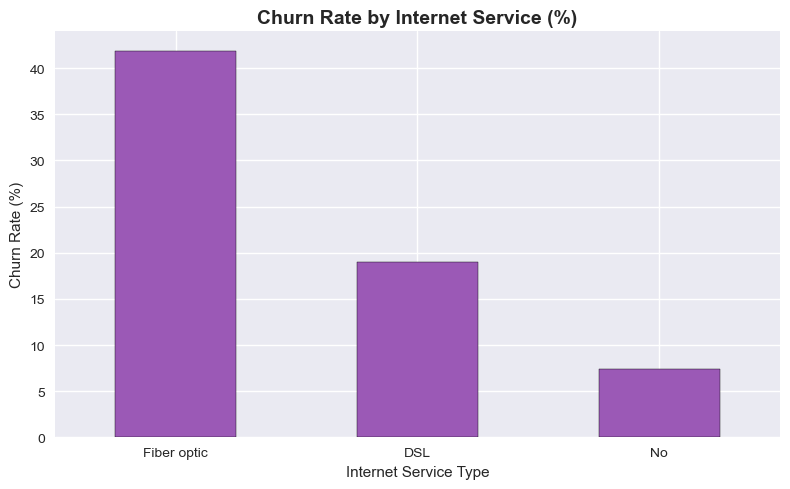

✅ Chart saved!


In [8]:
internet_churn = df.groupby('InternetService')['Churn_Flag'].mean() * 100

plt.figure(figsize=(8, 5))
internet_churn.sort_values(ascending=False).plot(
    kind='bar', color='#9b59b6', edgecolor='black')
plt.title('Churn Rate by Internet Service (%)', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(images_path, '03_churn_by_internet.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

<Figure size 900x500 with 0 Axes>

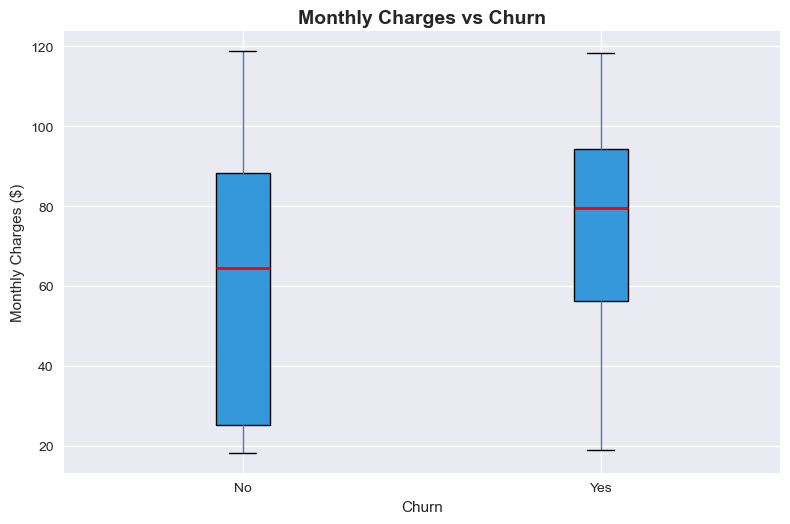

✅ Chart saved!


In [9]:
plt.figure(figsize=(9, 5))
df.boxplot(column='MonthlyCharges', by='Churn',
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='black'),
           medianprops=dict(color='red', linewidth=2))
plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig(os.path.join(images_path, '04_charges_vs_churn.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

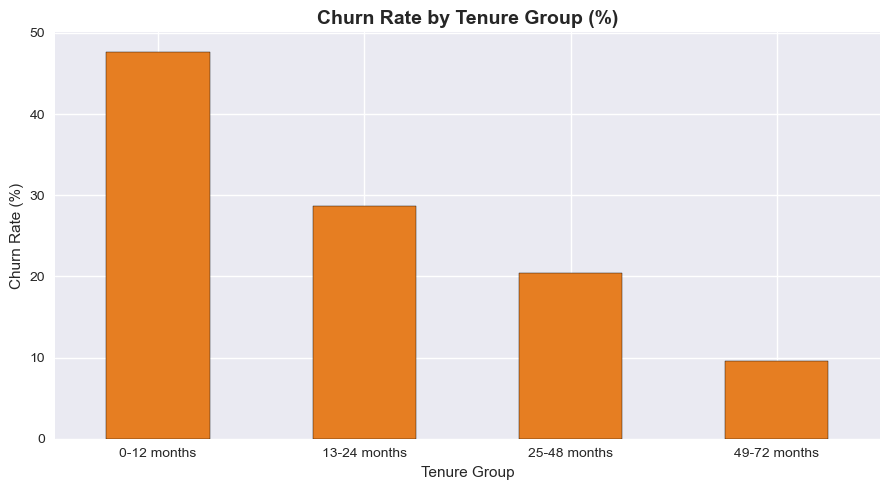

✅ Chart saved!


In [10]:
# Create tenure groups
df['Tenure_Group'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-12 months', '13-24 months', 
                                     '25-48 months', '49-72 months'])

tenure_churn = df.groupby('Tenure_Group', observed=True)['Churn_Flag'].mean() * 100

plt.figure(figsize=(9, 5))
tenure_churn.plot(kind='bar', color='#e67e22', edgecolor='black')
plt.title('Churn Rate by Tenure Group (%)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(images_path, '05_churn_by_tenure.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

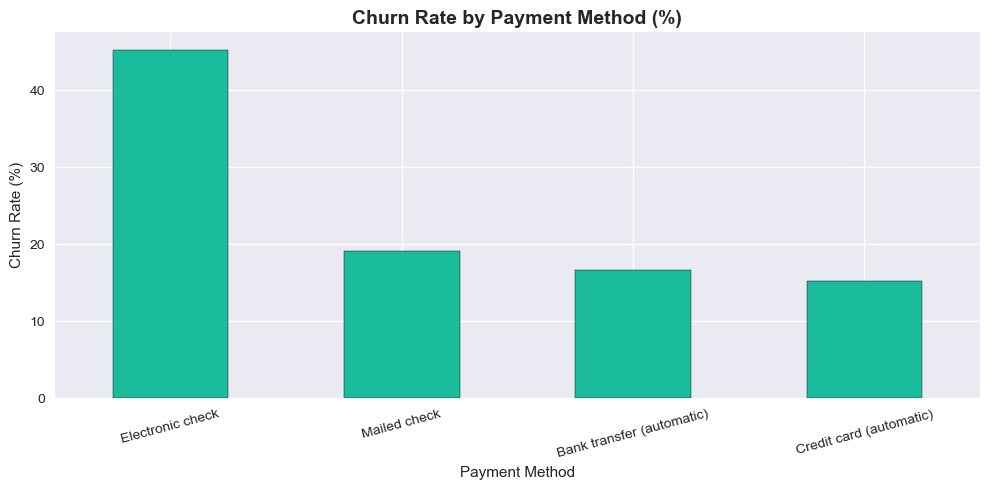

✅ Chart saved!


In [12]:
payment_churn = df.groupby('PaymentMethod')['Churn_Flag'].mean() * 100

plt.figure(figsize=(10, 5))
payment_churn.sort_values(ascending=False).plot(
    kind='bar', color='#1abc9c', edgecolor='black')
plt.title('Churn Rate by Payment Method (%)', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(images_path, '06_churn_by_payment.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

In [11]:
print("=" * 60)
print("      CUSTOMER CHURN ANALYSIS — KEY INSIGHTS")
print("=" * 60)

print(f"\n👥 Total Customers: {len(df):,}")
print(f"🚨 Overall Churn Rate: {df['Churn_Flag'].mean()*100:.1f}%")
print(f"❌ Customers Churned: {df['Churn_Flag'].sum():,}")

print("\n📋 Churn by Contract Type:")
print(df.groupby('Contract')['Churn_Flag'].mean().mul(100).round(1).to_string())

print("\n🌐 Churn by Internet Service:")
print(df.groupby('InternetService')['Churn_Flag'].mean().mul(100).round(1).to_string())

print("\n💳 Churn by Payment Method:")
print(df.groupby('PaymentMethod')['Churn_Flag'].mean().mul(100).round(1).to_string())

print("\n📅 Churn by Tenure Group:")
print(df.groupby('Tenure_Group', observed=True)['Churn_Flag'].mean().mul(100).round(1).to_string())

print("\n💰 Average Monthly Charges:")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2).to_string())

print("\n👴 Senior Citizen Churn Rate:")
print(df.groupby('SeniorCitizen')['Churn_Flag'].mean().mul(100).round(1).to_string())
print("=" * 60)

      CUSTOMER CHURN ANALYSIS — KEY INSIGHTS

👥 Total Customers: 7,043
🚨 Overall Churn Rate: 26.5%
❌ Customers Churned: 1,869

📋 Churn by Contract Type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8

🌐 Churn by Internet Service:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4

💳 Churn by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1

📅 Churn by Tenure Group:
Tenure_Group
0-12 months     47.7
13-24 months    28.7
25-48 months    20.4
49-72 months     9.5

💰 Average Monthly Charges:
Churn
No     61.27
Yes    74.44

👴 Senior Citizen Churn Rate:
SeniorCitizen
0    23.6
1    41.7


In [13]:
# Encode categorical columns
df_ml = df.copy()

# Label encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# One hot encode multi-category columns
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df_ml = pd.get_dummies(df_ml, columns=multi_cols, drop_first=True)

# Drop tenure group as we have tenure
df_ml.drop('Tenure_Group', axis=1, inplace=True)

print("✅ Data encoded!")
print("Shape:", df_ml.shape)
print("Columns:", list(df_ml.columns))

✅ Data encoded!
Shape: (7043, 32)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Flag', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Paths
project_path = os.path.join(os.path.expanduser("~"), "Desktop", "Customer_Churn_Project")
data_path = os.path.join(project_path, "data")
images_path = os.path.join(project_path, "images")

# Reload dataset
df = pd.read_csv(os.path.join(data_path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

# Clean data
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.drop('customerID', axis=1, inplace=True)
df['Tenure_Group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-12 months', '13-24 months',
                                     '25-48 months', '49-72 months'])

# Encode for ML
df_ml = df.copy()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df_ml = pd.get_dummies(df_ml, columns=multi_cols, drop_first=True)
df_ml.drop('Tenure_Group', axis=1, inplace=True)

# Split and scale
X = df_ml.drop(['Churn', 'Churn_Flag'], axis=1)
y = df_ml['Churn_Flag']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Everything restored and ready!")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

✅ Everything restored and ready!
Training set: (5634, 30)
Test set: (1409, 30)


In [18]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Logistic Regression trained!")
print(f"\nAccuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

✅ Logistic Regression trained!

Accuracy: 80.70%
ROC-AUC Score: 0.8416

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [19]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained!")
print(f"\nAccuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

✅ Random Forest trained!

Accuracy: 78.71%
ROC-AUC Score: 0.8215

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



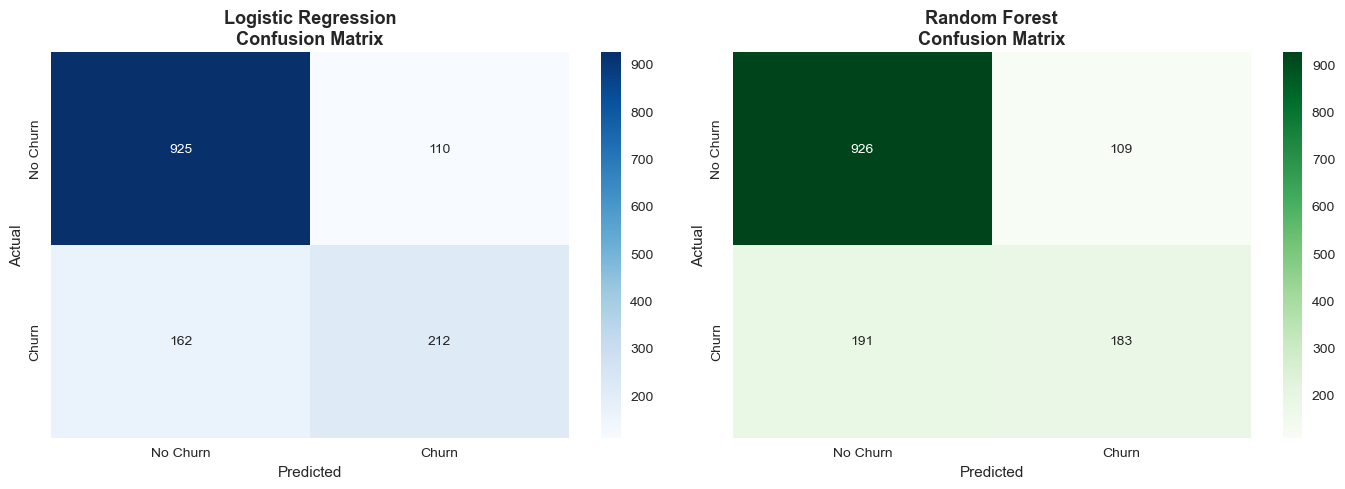

✅ Chart saved!


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'], ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'], ax=axes[1])
axes[1].set_title('Random Forest\nConfusion Matrix',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(os.path.join(images_path, '07_confusion_matrix.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

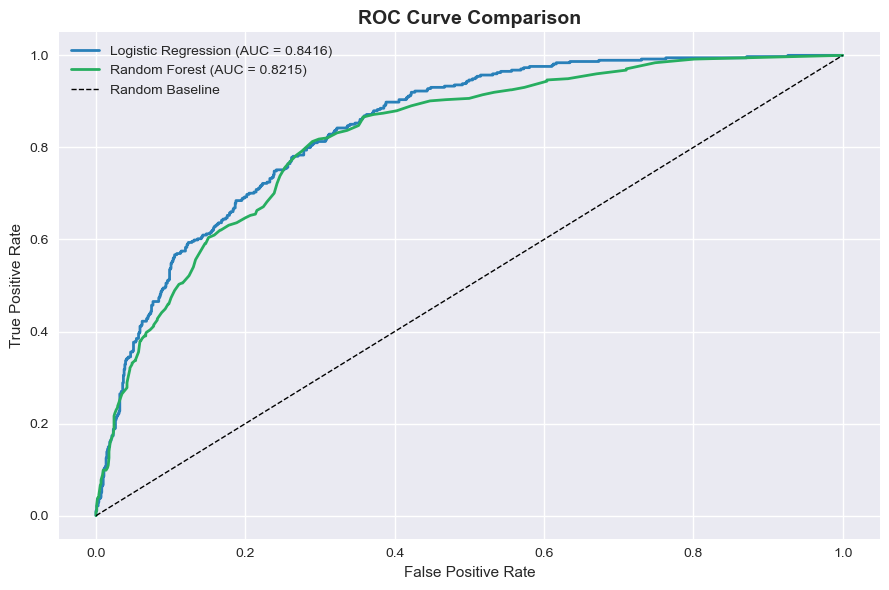

✅ Chart saved!


In [21]:
plt.figure(figsize=(9, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr_lr, tpr_lr, color='#2980b9', linewidth=2,
         label=f'Logistic Regression (AUC = 0.8416)')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr_rf, tpr_rf, color='#27ae60', linewidth=2,
         label=f'Random Forest (AUC = 0.8215)')

# Baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')

plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(images_path, '08_roc_curve.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

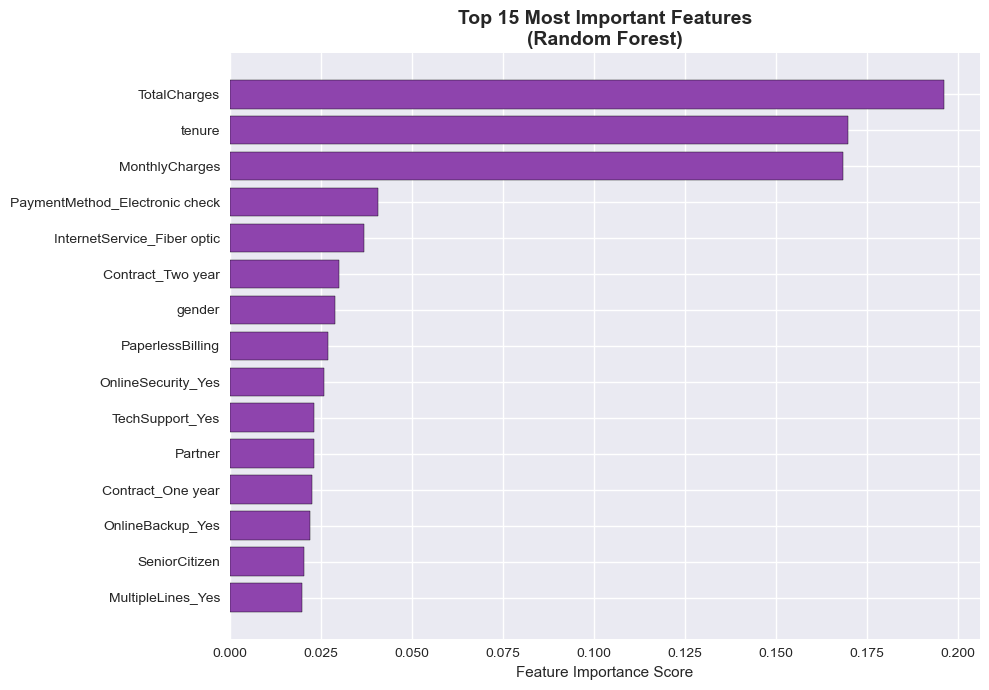

✅ Chart saved!


In [22]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 7))
plt.barh(feature_importance['Feature'], 
         feature_importance['Importance'],
         color='#8e44ad', edgecolor='black')
plt.title('Top 15 Most Important Features\n(Random Forest)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(images_path, '09_feature_importance.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

In [23]:
print("=" * 60)
print("         ML MODEL RESULTS SUMMARY")
print("=" * 60)

print("\n🤖 Logistic Regression:")
print(f"   Accuracy:  {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"   ROC-AUC:   {roc_auc_score(y_test, lr_prob):.4f}")

print("\n🌲 Random Forest:")
print(f"   Accuracy:  {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"   ROC-AUC:   {roc_auc_score(y_test, rf_prob):.4f}")

print("\n🏆 Best Model: Logistic Regression")
print("   → Higher accuracy and ROC-AUC score")
print("   → Better at identifying churning customers")

print("\n📊 What the model predicts correctly:")
cm = confusion_matrix(y_test, lr_pred)
print(f"   ✅ Correctly identified {cm[0][0]} customers who stayed")
print(f"   ✅ Correctly identified {cm[1][1]} customers who churned")
print(f"   ❌ Missed {cm[1][0]} churning customers (False Negatives)")
print(f"   ❌ Wrong alerts for {cm[0][1]} customers (False Positives)")

print("\n💡 Business Impact:")
print(f"   Model can identify {cm[1][1]/374*100:.1f}% of churning customers")
print(f"   Allowing proactive retention for {cm[1][1]} at-risk customers")
print("=" * 60)

         ML MODEL RESULTS SUMMARY

🤖 Logistic Regression:
   Accuracy:  80.70%
   ROC-AUC:   0.8416

🌲 Random Forest:
   Accuracy:  78.71%
   ROC-AUC:   0.8215

🏆 Best Model: Logistic Regression
   → Higher accuracy and ROC-AUC score
   → Better at identifying churning customers

📊 What the model predicts correctly:
   ✅ Correctly identified 925 customers who stayed
   ✅ Correctly identified 212 customers who churned
   ❌ Missed 162 churning customers (False Negatives)
   ❌ Wrong alerts for 110 customers (False Positives)

💡 Business Impact:
   Model can identify 56.7% of churning customers
   Allowing proactive retention for 212 at-risk customers


In [24]:
# Save clean dataset
df.to_csv(os.path.join(data_path, "telco_churn_clean.csv"), index=False)
print("✅ Clean dataset saved!")

✅ Clean dataset saved!


In [3]:
import os

project_path = os.path.join(os.path.expanduser("~"), "Desktop", "Customer_Churn_Project")

print("📁 FINAL PROJECT CHECK — CUSTOMER CHURN")
print("=" * 45)
for folder in ["data", "images", "sql", "dashboard", "notebooks"]:
    folder_path = os.path.join(project_path, folder)
    try:
        files = [f for f in os.listdir(folder_path) if not f.startswith('.')]
        print(f"\n📂 {folder}/")
        for file in files:
            print(f"   ✅ {file}")
    except:
        print(f"\n📂 {folder}/ ⚠️ Not found")

📁 FINAL PROJECT CHECK — CUSTOMER CHURN

📂 data/
   ✅ telco_churn_clean.csv
   ✅ WA_Fn-UseC_-Telco-Customer-Churn.csv

📂 images/
   ✅ 01_churn_distribution.png
   ✅ 02_churn_by_contract.png
   ✅ 03_churn_by_internet.png
   ✅ 04_charges_vs_churn.png
   ✅ 05_churn_by_tenure.png
   ✅ 06_churn_by_payment.png
   ✅ 07_confusion_matrix.png
   ✅ 08_roc_curve.png
   ✅ 09_feature_importance.png

📂 sql/
   ✅ churn_queries.sql

📂 dashboard/
   ✅ Customer_churn.pbix
   ✅ dashboard_screenshot.png

📂 notebooks/
   ✅ customer_churn_analysis.ipynb


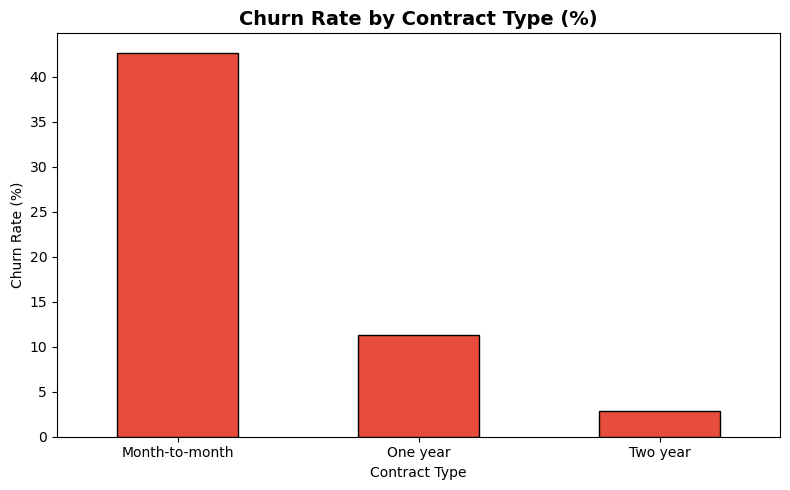

✅ Chart saved!


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

project_path = os.path.join(os.path.expanduser("~"), "Desktop", "Customer_Churn_Project")
images_path = os.path.join(project_path, "data")
images_path = os.path.join(project_path, "images")

df = pd.read_csv(os.path.join(project_path, "data", "telco_churn_clean.csv"))

contract_churn = df.groupby('Contract')['Churn_Flag'].mean() * 100

plt.figure(figsize=(8, 5))
contract_churn.sort_values(ascending=False).plot(
    kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Churn Rate by Contract Type (%)', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(images_path, '02_churn_by_contract.png'), dpi=150)
plt.show()
print("✅ Chart saved!")